# Tải và xử lý dữ liệu

In [ ]:
!pip install git+https://github.com/thinh-vu/vnstock

import numpy as np
from vnstock import Quote

quote = Quote(symbol="VNINDEX", source="KBS")
df = quote.history(
    symbol="VNINDEX",
    start="2023-08-01",
    end="2026-08-02",
    interval="1D"
)
df.to_csv('3y-vnindex_data.csv', index=False, encoding='utf-8-sig')


  Cloning https://github.com/thinh-vu/vnstock to /tmp/pip-req-build-xow46f1y
  Running command git clone --filter=blob:none --quiet https://github.com/thinh-vu/vnstock /tmp/pip-req-build-xow46f1y
  Resolved https://github.com/thinh-vu/vnstock to commit 72e6a75016da96173fd7dd26f1011e14fb3dfbf7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np


TICKER = "BTC-USD"
START_DATE = "2023-08-01"
END_DATE = "2026-08-02"  # end là ngày loại trừ
OUTPUT_FILE = "3y-bitcoin-price-clean.csv"


# =========================================================
# 1. TẢI DỮ LIỆU
# =========================================================

btc = yf.download(
    tickers=TICKER,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=True,
    threads=False
)

if btc.empty:
    raise RuntimeError("Không tải được dữ liệu BTC-USD từ Yahoo Finance.")

btc = btc.reset_index()


# =========================================================
# 2. XỬ LÝ MULTIINDEX
# =========================================================

if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = btc.columns.get_level_values(0)

# Loại tên cột trùng nếu yfinance trả về cấu trúc bất thường
btc = btc.loc[:, ~btc.columns.duplicated()].copy()


# =========================================================
# 3. KIỂM TRA CÁC CỘT BẮT BUỘC
# =========================================================

required_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

missing_columns = [
    col for col in required_columns
    if col not in btc.columns
]

if missing_columns:
    raise ValueError(
        f"Dữ liệu thiếu các cột bắt buộc: {missing_columns}"
    )

btc = btc[required_columns].copy()


# =========================================================
# 4. CHUẨN HÓA NGÀY
# =========================================================

btc["Date"] = pd.to_datetime(
    btc["Date"],
    errors="coerce",
    utc=True
).dt.tz_localize(None).dt.normalize()

# Loại dòng không chuyển đổi được ngày
btc = btc.dropna(subset=["Date"])

# Chỉ giữ đúng khoảng thời gian yêu cầu
btc = btc[
    (btc["Date"] >= pd.Timestamp(START_DATE))
    & (btc["Date"] < pd.Timestamp(END_DATE))
].copy()


# =========================================================
# 5. CHUYỂN CÁC CỘT GIÁ VỀ DẠNG SỐ
# =========================================================

price_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close"
]

for col in price_columns:
    btc[col] = pd.to_numeric(btc[col], errors="coerce")

btc["Volume"] = pd.to_numeric(
    btc["Volume"],
    errors="coerce"
)


# =========================================================
# 6. LOẠI DÒNG THIẾU HOẶC CÓ GIÁ KHÔNG HỢP LỆ
# =========================================================

# Thay giá trị vô cực bằng NaN
btc = btc.replace([np.inf, -np.inf], np.nan)

# OHLC và Close phải tồn tại để kiểm tra dữ liệu
btc = btc.dropna(
    subset=["Open", "High", "Low", "Close"]
).copy()

# Giá phải lớn hơn 0
valid_positive_price = (
    btc[["Open", "High", "Low", "Close"]] > 0
).all(axis=1)

btc = btc.loc[valid_positive_price].copy()


# =========================================================
# 7. KIỂM TRA TÍNH NHẤT QUÁN CỦA OHLC
# =========================================================

valid_ohlc = (
    (btc["High"] >= btc["Open"])
    & (btc["High"] >= btc["Close"])
    & (btc["High"] >= btc["Low"])
    & (btc["Low"] <= btc["Open"])
    & (btc["Low"] <= btc["Close"])
)

invalid_ohlc_count = (~valid_ohlc).sum()

if invalid_ohlc_count > 0:
    print(
        f"Cảnh báo: loại {invalid_ohlc_count} dòng có OHLC không hợp lệ."
    )

btc = btc.loc[valid_ohlc].copy()


# =========================================================
# 8. XỬ LÝ VOLUME
# =========================================================

# Volume không phải biến dùng để tính return nên không loại dòng
# chỉ vì Volume bị thiếu.
btc.loc[btc["Volume"] < 0, "Volume"] = np.nan


# =========================================================
# 9. SẮP XẾP VÀ LOẠI NGÀY TRÙNG
# =========================================================

btc = (
    btc.sort_values("Date")
       .drop_duplicates(subset=["Date"], keep="last")
       .reset_index(drop=True)
)


# =========================================================
# 10. CHỌN GIÁ DÙNG CHO NGHIÊN CỨU
# =========================================================

# Với BTC, dùng Close làm giá đại diện cuối ngày.
btc = btc.rename(columns={"Close": "btc_price"})

btc = btc[
    [
        "Date",
        "Open",
        "High",
        "Low",
        "btc_price",
        "Adj Close",
        "Volume"
    ]
].copy()


# =========================================================
# 11. KIỂM TRA KHOẢNG CÁCH NGÀY
# =========================================================

btc["day_gap"] = btc["Date"].diff().dt.days

missing_calendar_days = (
    btc.loc[btc["day_gap"] > 1, ["Date", "day_gap"]]
)

if not missing_calendar_days.empty:
    print("\nCác vị trí có khoảng cách lớn hơn 1 ngày:")
    print(missing_calendar_days.to_string(index=False))


# =========================================================
# 12. LƯU CHUỖI GIÁ SẠCH
# =========================================================

btc.to_csv(
    OUTPUT_FILE,
    index=False,
    date_format="%Y-%m-%d"
)


# =========================================================
# 13. BÁO CÁO
# =========================================================

print("\n5 dòng đầu:")
print(btc.head())

print("\n5 dòng cuối:")
print(btc.tail())

print(f"\nSố quan sát sạch: {len(btc):,}")
print(f"Từ ngày: {btc['Date'].min():%Y-%m-%d}")
print(f"Đến ngày: {btc['Date'].max():%Y-%m-%d}")
print(f"Số ngày bị trùng: {btc['Date'].duplicated().sum()}")
print(f"Số giá BTC không hợp lệ: {(btc['btc_price'] <= 0).sum()}")
print(f"Đã lưu: {OUTPUT_FILE}")

[*********************100%***********************]  1 of 1 completed


5 dòng đầu:
Price       Date          Open          High           Low     btc_price  \
0     2023-08-01  29230.873047  29675.732422  28657.023438  29675.732422   
1     2023-08-02  29704.146484  29987.998047  28946.509766  29151.958984   
2     2023-08-03  29161.812500  29375.707031  28959.488281  29178.679688   
3     2023-08-04  29174.382812  29302.078125  28885.335938  29074.091797   
4     2023-08-05  29075.388672  29102.464844  28957.796875  29042.126953   

Price     Adj Close        Volume  day_gap  
0      29675.732422  1.827239e+10      NaN  
1      29151.958984  1.921266e+10      1.0  
2      29178.679688  1.278036e+10      1.0  
3      29074.091797  1.203664e+10      1.0  
4      29042.126953  6.598366e+09      1.0  

5 dòng cuối:
Price       Date          Open          High           Low     btc_price  \
1092  2026-07-28  63723.488281  64026.921875  62714.804688  63871.363281   
1093  2026-07-29  63871.394531  64638.695312  63206.210938  63908.167969   
1094  2026-07-30  

In [ ]:
# Data usd vnd exchange
import yfinance as yf
import pandas as pd
import numpy as np


START_DATE = "2023-08-01"
END_DATE = "2026-08-02"   # yfinance không bao gồm END_DATE
OUTPUT_FILE = "3y-usdvnd-price-clean.csv"


usdvnd = yf.download(
    tickers="VND=X",
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=True,
    threads=False
)

if usdvnd.empty:
    raise RuntimeError("Không tải được dữ liệu USD/VND.")

usdvnd = usdvnd.reset_index()

# Xử lý MultiIndex
if isinstance(usdvnd.columns, pd.MultiIndex):
    usdvnd.columns = usdvnd.columns.get_level_values(0)

usdvnd = usdvnd.loc[:, ~usdvnd.columns.duplicated()].copy()

# Chỉ cần Date và Close
if not {"Date", "Close"}.issubset(usdvnd.columns):
    raise ValueError(
        f"Thiếu cột Date hoặc Close. Các cột hiện có: "
        f"{usdvnd.columns.tolist()}"
    )

usdvnd = usdvnd[["Date", "Close"]].copy()

# Chuẩn hóa ngày
usdvnd["Date"] = (
    pd.to_datetime(usdvnd["Date"], errors="coerce", utc=True)
      .dt.tz_localize(None)
      .dt.normalize()
)

# Chuẩn hóa tỷ giá
usdvnd["usdvnd_rate"] = pd.to_numeric(
    usdvnd["Close"],
    errors="coerce"
)

usdvnd = usdvnd.drop(columns="Close")
usdvnd = usdvnd.replace([np.inf, -np.inf], np.nan)
usdvnd = usdvnd.dropna(subset=["Date", "usdvnd_rate"])
usdvnd = usdvnd.loc[usdvnd["usdvnd_rate"] > 0]

# Sắp xếp và loại ngày trùng
usdvnd = (
    usdvnd.sort_values("Date")
          .drop_duplicates(subset="Date", keep="last")
          .reset_index(drop=True)
)

usdvnd.to_csv(
    OUTPUT_FILE,
    index=False,
    date_format="%Y-%m-%d"
)

print(usdvnd.head())
print(usdvnd.tail())
print(f"Số quan sát: {len(usdvnd):,}")
print(f"Từ ngày: {usdvnd['Date'].min():%Y-%m-%d}")
print(f"Đến ngày: {usdvnd['Date'].max():%Y-%m-%d}")
print(f"Đã lưu: {OUTPUT_FILE}")

[*********************100%***********************]  1 of 1 completed

Price       Date  usdvnd_rate
0     2023-08-01      23680.0
1     2023-08-02      23680.0
2     2023-08-03      23735.0
3     2023-08-04      23750.0
4     2023-08-07      23725.0
Price       Date  usdvnd_rate
774   2026-07-27      26300.0
775   2026-07-28      26313.0
776   2026-07-29      26330.0
777   2026-07-30      26321.0
778   2026-07-31      26279.0
Số quan sát: 779
Từ ngày: 2023-08-01
Đến ngày: 2026-07-31
Đã lưu: 3y-usdvnd-price-clean.csv


In [ ]:
print(usdvnd.info())
print("\nSố ngày trùng:", usdvnd["Date"].duplicated().sum())
print("Số tỷ giá thiếu:", usdvnd["usdvnd_rate"].isna().sum())
print("Số tỷ giá không dương:", (usdvnd["usdvnd_rate"] <= 0).sum())
print("\nThống kê tỷ giá:")
print(usdvnd["usdvnd_rate"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779 entries, 0 to 778
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         779 non-null    datetime64[ns]
 1   usdvnd_rate  779 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 12.3 KB
None

Số ngày trùng: 0
Số tỷ giá thiếu: 0
Số tỷ giá không dương: 0

Thống kê tỷ giá:
count      779.000000
mean     25469.903723
std        769.394006
min      23680.000000
25%      24787.500000
50%      25450.000000
75%      26254.500000
max      26425.000000
Name: usdvnd_rate, dtype: float64


In [ ]:
import pandas as pd
vnindex_data = pd.read_csv('3y-vnindex_data.csv')

print(vnindex_data.info())
print("\nSố ngày trùng:", vnindex_data["time"].duplicated().sum())
print("Số chỉ số thiếu:", vnindex_data["close"].isna().sum())
print("\nThống kê tỷ giá:")
print(vnindex_data["close"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    748 non-null    object 
 1   open    748 non-null    float64
 2   high    748 non-null    float64
 3   low     748 non-null    float64
 4   close   748 non-null    float64
 5   volume  748 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 35.2+ KB
None

Số ngày trùng: 0
Số chỉ số thiếu: 0

Thống kê tỷ giá:
count     748.000000
mean     1413.238195
std       252.281017
min      1028.190000
25%      1236.780000
50%      1281.935000
75%      1667.042500
max      1927.940000
Name: close, dtype: float64


In [ ]:
vnindex = pd.read_csv("3y-vnindex_data.csv")

vnindex["Date"] = (
    pd.to_datetime(
        vnindex["time"],
        errors="coerce"
    )
    .dt.normalize()
)

vnindex["vnindex_price"] = pd.to_numeric(
    vnindex["close"],
    errors="coerce"
)

vnindex_clean = (
    vnindex[["Date", "vnindex_price"]]
    .dropna(subset=["Date", "vnindex_price"])
    .sort_values("Date")
    .drop_duplicates(subset="Date", keep="last")
    .reset_index(drop=True)
)
vnindex_clean.info()

# Lưu data
vnindex_clean.to_csv('3y-vnindex-data-clean.csv',
                     index=False,
                     date_format="%Y-%m-%d")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           748 non-null    datetime64[ns]
 1   vnindex_price  748 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.8 KB


In [ ]:
gold = pd.read_csv('3y-sjc.csv')
print(gold.info())
print(gold.head())
print(gold.tail())

print("\nSố ngày trùng:", gold["query_date"].duplicated().sum())
print("Số giá bán thiếu:", gold['buy'].isna().sum())
print("Số giá mua thiếu:", gold["sell"].isna().sum())

print("\nThống kê giá:")
print(gold['buy'].describe())
print(gold['sell'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910 entries, 0 to 909
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query_date  910 non-null    int64 
 1   location    910 non-null    object
 2   product     910 non-null    object
 3   buy         910 non-null    int64 
 4   sell        910 non-null    int64 
 5   updated_at  910 non-null    object
 6   crawl_time  910 non-null    object
dtypes: int64(3), object(4)
memory usage: 49.9+ KB
None
   query_date location product    buy   sell           updated_at  \
0    20230801    TPHCM     SJC  66600  67200  2023-01-08 08:20:36   
1    20230802    TPHCM     SJC  66700  67250  2023-08-02 08:26:11   
2    20230803    TPHCM     SJC  66700  67200  2023-03-08 08:24:26   
3    20230804    TPHCM     SJC  66700  67250  2023-08-04 08:47:02   
4    20230805    TPHCM     SJC  66700  67250  2023-05-08 08:09:05   

                   crawl_time  
0  2026-08-04 15:06:58.496180  
1

In [ ]:
import pandas as pd
import numpy as np

# 1. Dùng query_date làm ngày chính xác
gold["Date"] = pd.to_datetime(
    gold["query_date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# 2. Chuẩn hóa giá
gold["buy"] = pd.to_numeric(gold["buy"], errors="coerce")
gold["sell"] = pd.to_numeric(gold["sell"], errors="coerce")

gold = gold.replace([np.inf, -np.inf], np.nan)

# 3. Chỉ giữ các quan sát hợp lệ
gold = gold.dropna(subset=["Date", "buy", "sell"]).copy()

gold = gold.loc[
    (gold["buy"] > 0)
    & (gold["sell"] > 0)
    & (gold["sell"] >= gold["buy"])
].copy()

# 4. Tính giá vàng đại diện: midpoint
gold["gold_price"] = (
    gold["buy"] + gold["sell"]
) / 2

gold_clean = (
    gold[
        [
            "Date",
            "location",
            "product",
            "buy",
            "sell",
            "gold_price"
        ]
    ]
    .sort_values("Date")
    .drop_duplicates(subset=["Date"], keep="last")
    .reset_index(drop=True)
)

gold_clean.to_csv(
    "3y-sjc-price-clean.csv",
    index=False,
    date_format="%Y-%m-%d"
)

In [ ]:
# ghép dataset theo 'Date'
# 1. CHUẨN HÓA CỘT DATE

for dataframe in [gold, btc, usdvnd, vnindex_clean]:
    dataframe["Date"] = (
        pd.to_datetime(
            dataframe["Date"],
            errors="coerce",
            utc=True
        )
        .dt.tz_localize(None)
        .dt.normalize()
    )
# 2. GHÉP BTC-USD VỚI USDVND
btc_vnd = btc.merge(
    usdvnd,
    on="Date",
    how="inner",
    validate="one_to_one"
)

btc_vnd["btc_vnd_price"] = (
    btc_vnd["btc_price"]
    * btc_vnd["usdvnd_rate"]
)

In [ ]:
# 3. GHÉP 3 CHUỖI TÀI SẢN THEO DATE
prices = (
    btc_vnd[
        [
            "Date",
            "btc_price",
            "usdvnd_rate",
            "btc_vnd_price"
        ]
    ]
    .merge(
        gold[["Date", "gold_price"]],
        on="Date",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        vnindex_clean[["Date", "vnindex_price"]],
        on="Date",
        how="inner",
        validate="one_to_one"
    )
    .sort_values("Date")
    .reset_index(drop=True)
)
# 4. KIỂM TRA GIÁ HỢP LỆ
price_columns = [
    "btc_vnd_price",
    "gold_price",
    "vnindex_price"
]

prices[price_columns] = prices[price_columns].replace(
    [np.inf, -np.inf],
    np.nan
)

valid_prices = (
    prices[price_columns].notna().all(axis=1)
    & prices[price_columns].gt(0).all(axis=1)
)

prices = prices.loc[valid_prices].reset_index(drop=True)

In [ ]:
# 5. TÍNH LOG-RETURN SAU KHI GHÉP

prices["btc_return"] = (
    100
    * np.log(
        prices["btc_vnd_price"]
        / prices["btc_vnd_price"].shift(1)
    )
)

prices["gold_return"] = (
    100
    * np.log(
        prices["gold_price"]
        / prices["gold_price"].shift(1)
    )
)

prices["vnindex_return"] = (
    100
    * np.log(
        prices["vnindex_price"]
        / prices["vnindex_price"].shift(1)
    )
)

In [ ]:
# 6. TẠO DATASET RETURN HOÀN CHỈNH

returns = prices.dropna(
    subset=[
        "btc_return",
        "gold_return",
        "vnindex_return"
    ]
).reset_index(drop=True)


# 7. LƯU KẾT QUẢ

prices.to_csv(
    "3y-merged-prices.csv",
    index=False,
    date_format="%Y-%m-%d"
)

returns.to_csv(
    "3y-merged-returns.csv",
    index=False,
    date_format="%Y-%m-%d"
)

In [ ]:
print("\n5 dòng đầu của dataset giá:")
print(prices.head())

print("\n5 dòng cuối của dataset giá:")
print(prices.tail())

print(f"\nSố ngày chung có đủ ba tài sản: {len(prices):,}")
print(f"Từ ngày: {prices['Date'].min():%Y-%m-%d}")
print(f"Đến ngày: {prices['Date'].max():%Y-%m-%d}")
print("Số ngày trùng:", prices["Date"].duplicated().sum())

print("\nSố giá thiếu:")
print(prices[price_columns].isna().sum())

print("\nSố quan sát return:", len(returns))

print("\nThống kê log-return:")
print(
    returns[
        [
            "btc_return",
            "gold_return",
            "vnindex_return"
        ]
    ].describe()
)



5 dòng đầu của dataset giá:
        Date     btc_price  usdvnd_rate  btc_vnd_price  gold_price  \
0 2023-08-01  29675.732422      23680.0   7.027213e+08     66900.0   
1 2023-08-02  29151.958984      23680.0   6.903184e+08     66975.0   
2 2023-08-03  29178.679688      23735.0   6.925560e+08     66950.0   
3 2023-08-04  29074.091797      23750.0   6.905097e+08     66975.0   
4 2023-08-07  29180.578125      23725.0   6.923092e+08     67025.0   

   vnindex_price  btc_return  gold_return  vnindex_return  
0        1217.56         NaN          NaN             NaN  
1        1220.43   -1.780751     0.112045        0.235440  
2        1210.95    0.323612    -0.037334       -0.779808  
3        1225.98   -0.295906     0.037334        1.233535  
4        1241.42    0.260271     0.074627        1.251536  

5 dòng cuối của dataset giá:
          Date     btc_price  usdvnd_rate  btc_vnd_price  gold_price  \
740 2026-07-27  63724.898438      26300.0   1.675965e+09    141000.0   
741 2026-07-28  

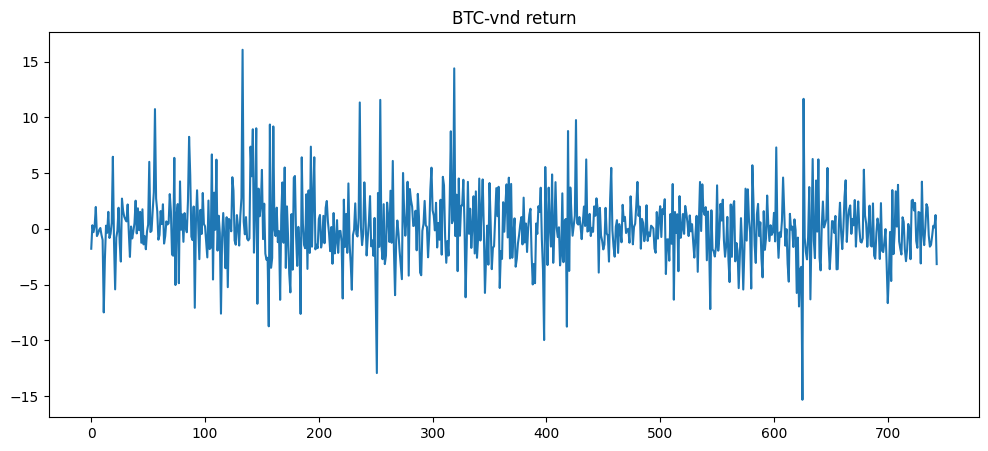

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(returns['btc_return'])
plt.title("BTC-vnd return")
plt.show()

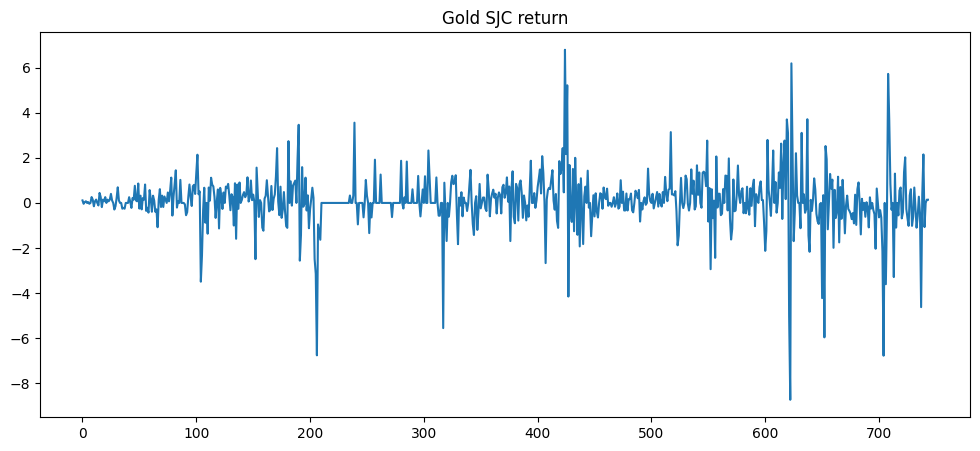

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(returns['gold_return'])
plt.title("Gold SJC return")
plt.show()

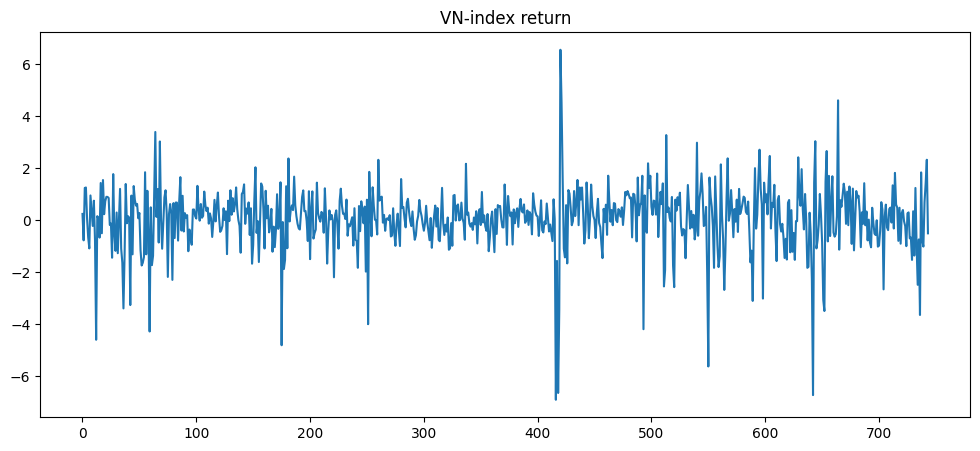

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(returns['vnindex_return'])
plt.title("VN-index return")
plt.show()